# Job Market Intelligence – Exploratory Data Analysis

This notebook explores the cleaned No Fluff Jobs dataset to identify patterns in job demand, experience levels, workplace models, contract types, salaries, and technologies.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "nofluff_it_jobs_clean.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (3309, 29)


## Analysis plan

The exploratory analysis focuses on four main questions:

1. What experience levels are most in demand?
2. What workplace models and contract types are most common?
3. How do salaries differ across experience levels and job categories?
4. Which technologies and skills are most frequently required?

## 1. Dataset overview

This section provides a high-level overview of the dataset, including the number
of job offers, companies, categories, salary availability, and data collection period.


In [2]:
# Convert scraping date to datetime
df["scraped_at"] = pd.to_datetime(
    df["scraped_at"],
    errors="coerce"
)

overview = pd.Series({
    "Job offers": len(df),
    "Unique companies": df["company"].nunique(),
    "Unique job titles": df["title"].nunique(),
    "Unique categories": df["category"].nunique(),
    "Offers with salary": df["salary_min"].notna().sum(),
    "Salary analysis eligible": df["salary_analysis_eligible"].sum(),
})

overview

Job offers                  3309
Unique companies             386
Unique job titles           2646
Unique categories             50
Offers with salary          2342
Salary analysis eligible    2320
dtype: int64

In [3]:
salary_available_pct = (
    df["salary_min"].notna().mean() * 100
)

salary_eligible_pct = (
    df["salary_analysis_eligible"].mean() * 100
)

print(
    f"Offers with salary: "
    f"{salary_available_pct:.1f}%"
)

print(
    f"Offers eligible for salary analysis: "
    f"{salary_eligible_pct:.1f}%"
)

print()
print(
    "Data collection period:",
    df["scraped_at"].min().date(),
    "to",
    df["scraped_at"].max().date()
)

Offers with salary: 70.8%
Offers eligible for salary analysis: 70.1%

Data collection period: 2026-08-13 to 2026-08-15


In [4]:
df[
    [
        "title",
        "company",
        "experience",
        "workplace",
        "salary_min",
        "salary_max"
    ]
].head()

,title,company,experience,workplace,salary_min,salary_max
0,Architekt Danych / Tech Lead Data Platform (pr...,Moondigo Sp. z o.o.,Senior,Hybrid,28560.0,31920.0
1,Architekt Danych / Tech Lead K/M,ASTEK Polska,Mid,Hybrid,25200.0,33600.0
2,Azure Data Platform Engineer [M/F],Stackmine,Mid,Remote,26880.0,32760.0
3,Business Analyst,Mindbox Sp. z o.o.,Senior,Hybrid,21000.0,25200.0
4,Data Analyst,Ework Group,Senior,Hybrid,23520.0,26880.0


### Key observations

- The dataset contains 3,309 unique job offers from 386 companies.
- There are 2,646 unique job titles, which indicates high diversity in job naming.
- Salary information is available for 70.8% of offers.
- 70.1% of all offers meet the criteria used for salary analysis.
- The data was collected between August 13 and August 15, 2026.
- The dataset contains 50 unique category values; some of them may represent combinations of multiple job categories rather than single categories.

## 2. Experience level

This section examines the distribution of job offers across different experience levels.

In [5]:
experience_counts = (
    df["experience"]
    .value_counts(dropna=False)
    .to_frame("job_offers")
)

experience_counts

,job_offers
experience,
Senior,1751
Mid,1229
Junior,140
Expert,139
NaN,50


In [6]:
experience_summary = (
    df["experience"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("experience")
    .reset_index(name="job_offers")
)

experience_summary["percentage"] = (
    experience_summary["job_offers"]
    / len(df)
    * 100
).round(1)

experience_summary

,experience,job_offers,percentage
0,Senior,1751,52.9
1,Mid,1229,37.1
2,Junior,140,4.2
3,Expert,139,4.2
4,Missing,50,1.5


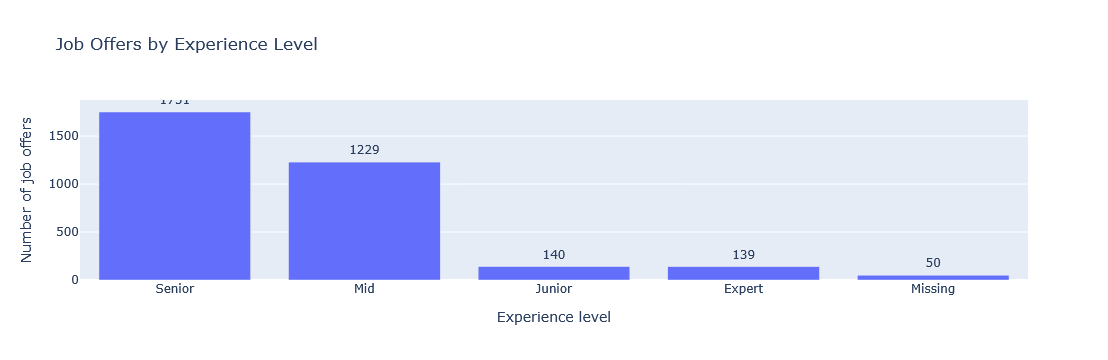

In [7]:
import plotly.express as px

experience_order = [
    "Senior",
    "Mid",
    "Junior",
    "Expert",
    "Missing"
]

fig = px.bar(
    experience_summary,
    x="experience",
    y="job_offers",
    text="job_offers",
    category_orders={
        "experience": experience_order
    },
    title="Job Offers by Experience Level",
    labels={
        "experience": "Experience level",
        "job_offers": "Number of job offers"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

### Key observation

Senior and Mid-level positions dominate the dataset, accounting for approximately
90% of all job offers. Senior roles alone represent more than half of the analysed
job market, while Junior positions account for only around 5.5%.

This suggests that the analysed IT job market is strongly oriented toward
experienced professionals.

In [8]:
df['experience_years_min'].describe()

count    1729.000000
mean        4.746674
std         1.931861
min         0.000000
25%         3.000000
50%         5.000000
75%         5.000000
max        15.000000
Name: experience_years_min, dtype: float64

In [9]:
df.groupby('experience')['experience_years_min'].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
Expert,74.0,6.770270,2.320530,3.0,5.00,7.0,8.0,15.0
Junior,50.0,2.980000,2.084833,0.0,1.25,2.0,5.0,10.0
Mid,623.0,3.730337,1.691047,1.0,3.00,3.0,5.0,10.0
Senior,981.0,5.332314,1.634346,1.0,5.00,5.0,6.0,15.0


In [10]:
liczba = ((df['experience'] == 'Junior') & (df['experience_years_min'] > 5)).sum()
print(liczba)
liczba = ((df['experience'] == 'Mid') & (df['experience_years_min'] > 10)).sum()
print(liczba)



3
0


In [11]:
junior_anomalies = df[
    (df["experience"] == "Junior")
    & (df["experience_years_min"] > 5)
][
    [
        "title",
        "company",
        "experience",
        "experience_years_min",
        "requirements"
    ]
]

junior_anomalies

,title,company,experience,experience_years_min,requirements
839,Frontend Developer,Mindbox Sp. z o.o.,Junior,7.0,Oryginalny tekst. Pokaż tłumaczenie 7+ years o...
1542,OT Network Support Specialist,Mindbox Sp. z o.o.,Junior,8.0,Oryginalny tekst. Pokaż tłumaczenie 8+ years o...
2853,ServiceNow Technical Lead - AI Solutions Delivery,Belvedere Recruitment,Junior,10.0,Oryginalny tekst. Pokaż tłumaczenie 10+ years ...


In [12]:
experience_years = (
    df.groupby("experience")["experience_years_min"]
    .agg(
        job_offers="count",
        median_years="median",
        mean_years="mean"
    )
    .round(1)
)

experience_years

,job_offers,median_years,mean_years
experience,,,
Expert,74,7.0,6.8
Junior,50,2.0,3.0
Mid,623,3.0,3.7
Senior,981,5.0,5.3


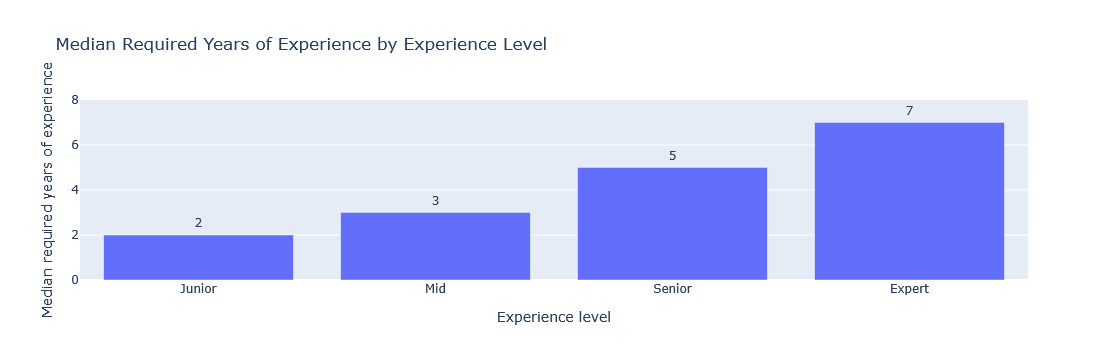

In [14]:
import plotly.express as px

experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

median_experience = (
    df.groupby("experience")["experience_years_min"]
    .median()
    .reindex(experience_order)
    .reset_index()
)

fig = px.bar(
    median_experience,
    x="experience",
    y="experience_years_min",
    text="experience_years_min",
    title="Median Required Years of Experience by Experience Level",
    labels={
        "experience": "Experience level",
        "experience_years_min": "Median required years"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    yaxis_title="Median required years of experience",
    xaxis_title="Experience level"
)

fig.update_yaxes(
    range=[0, 8]
)

fig.show()

In [16]:
df['workplace'].value_counts().sum()

np.int64(3009)

In [18]:
df.groupby('workplace')['job_id'].count() / df['job_id'].count() * 100

workplace
Hybrid    54.850408
Onsite     0.302206
Remote    35.781203
Name: job_id, dtype: float64

In [19]:
workplace_summary = (
    df["workplace"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("workplace")
    .reset_index(name="job_offers")
)

workplace_summary["percentage"] = (
    workplace_summary["job_offers"]
    / len(df)
    * 100
).round(1)

workplace_summary

,workplace,job_offers,percentage
0,Hybrid,1815,54.9
1,Remote,1184,35.8
2,Missing,300,9.1
3,Onsite,10,0.3


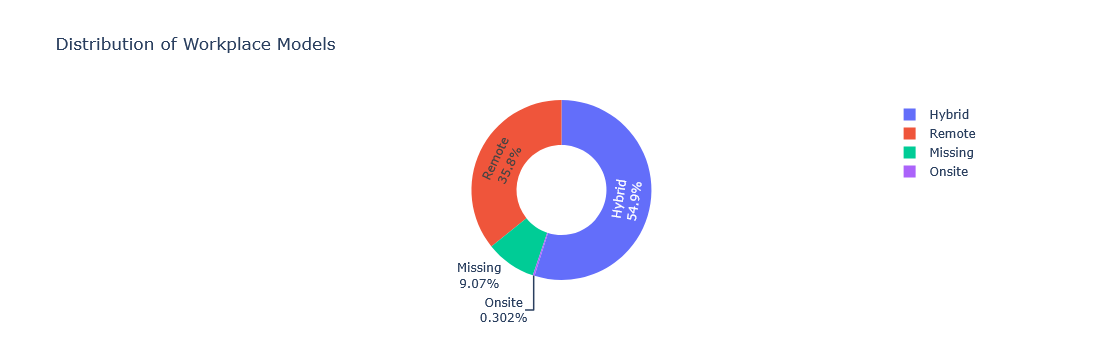

In [21]:
fig = px.pie(
    workplace_summary,
    names="workplace",
    values="job_offers",
    hole=0.5,
    title="Distribution of Workplace Models"
)

fig.update_traces(
    textinfo="percent+label"
)

fig.show()

In [22]:
workplace_experience = (
    pd.crosstab(
        df["experience"],
        df["workplace"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

workplace_experience

workplace,Hybrid,Missing,Onsite,Remote
experience,,,,
Expert,69.1,2.2,0.0,28.8
Junior,60.7,17.9,0.0,21.4
Mid,58.0,12.4,0.7,28.8
Senior,51.6,5.1,0.0,43.3


In [23]:
workplace_experience_plot = (
    workplace_experience
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="workplace",
        value_name="percentage"
    )
)

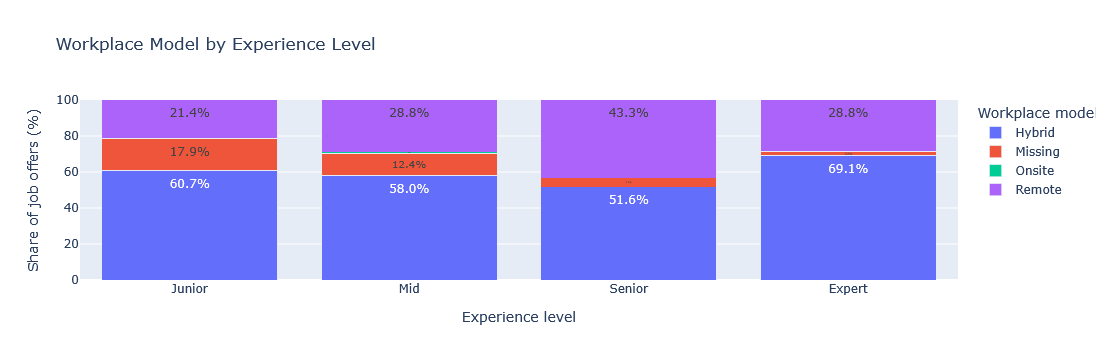

In [24]:
fig = px.bar(
    workplace_experience_plot,
    x="experience",
    y="percentage",
    color="workplace",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Workplace Model by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "workplace": "Workplace model"
    }
)

fig.update_layout(
    barmode="stack",
    yaxis_range=[0, 100]
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="inside"
)

fig.show()

## 4. Job categories

This section explores the distribution of job offers across different job categories.

Some offers contain multiple categories, so the initial analysis focuses on the raw category values before deciding whether they should be split into separate categories.

In [25]:
top_categories = (
    df["category"]
    .fillna("Missing")
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories

,category,job_offers
0,Backend,290
1,DevOps,247
2,Missing,244
3,Data,238
4,Testing,202
5,"Java, Backend",196
6,Security,184
7,ERP,182
8,Project Manager,177
9,Architecture,146


In [26]:
categories_exploded = (
    df[["job_id", "category"]]
    .dropna(subset=["category"])
    .assign(
        category=lambda x:
        x["category"].str.split(",")
    )
    .explode("category")
)

categories_exploded["category"] = (
    categories_exploded["category"]
    .str.strip()
)

In [27]:
top_categories_exploded = (
    categories_exploded["category"]
    .value_counts()
    .head(20)
    .rename_axis("category")
    .reset_index(name="job_offers")
)

top_categories_exploded

,category,job_offers
0,Backend,616
1,Data,326
2,Python,311
3,Java,310
4,DevOps,293
5,Testing,267
6,Fullstack,224
7,AI,204
8,Security,190
9,ERP,183


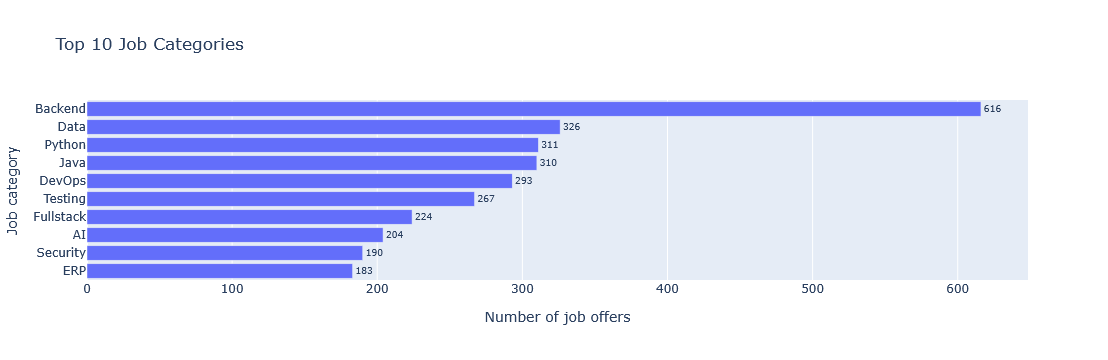

In [28]:
top_10_categories = (
    top_categories_exploded
    .head(10)
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    top_10_categories,
    x="job_offers",
    y="category",
    orientation="h",
    text="job_offers",
    title="Top 10 Job Categories",
    labels={
        "job_offers": "Number of job offers",
        "category": "Job category"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

In [29]:
top_10_category_names = (
    top_categories_exploded
    .head(10)["category"]
    .tolist()
)

category_experience_df = (
    categories_exploded
    .merge(
        df[
            [
                "job_id",
                "experience"
            ]
        ],
        on="job_id",
        how="left"
    )
)

category_experience_df = (
    category_experience_df[
        category_experience_df["category"]
        .isin(top_10_category_names)
    ]
    .dropna(subset=["experience"])
)

In [30]:
category_experience = (
    pd.crosstab(
        category_experience_df["category"],
        category_experience_df["experience"],
        normalize="index"
    )
    * 100
).round(1)

category_experience = (
    category_experience
    .reindex(
        index=top_10_category_names,
        columns=[
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ],
        fill_value=0
    )
)

category_experience

experience,Junior,Mid,Senior,Expert
category,,,,
Backend,4.8,30.1,62.0,3.1
Data,4.0,35.2,54.0,6.8
Python,3.5,30.0,62.9,3.5
Java,4.8,27.4,65.8,1.9
DevOps,2.8,34.5,60.7,2.1
Testing,6.5,49.4,41.8,2.3
Fullstack,0.9,33.2,63.2,2.7
AI,4.0,27.4,62.7,6.0
Security,3.2,48.1,43.9,4.8


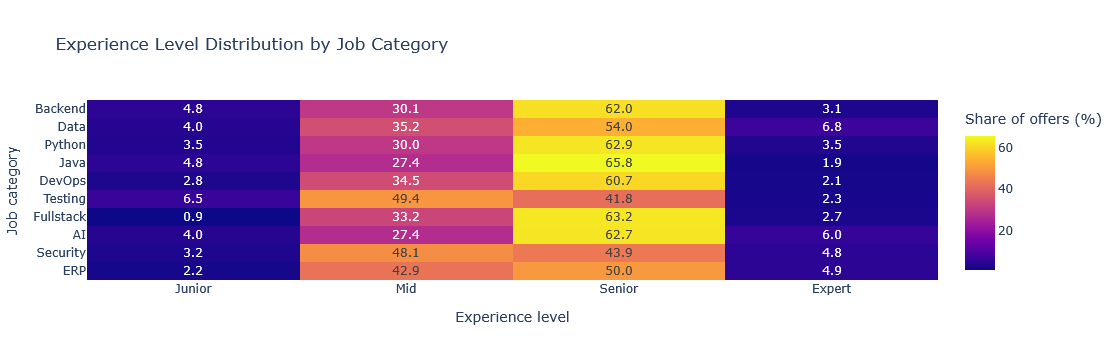

In [31]:
fig = px.imshow(
    category_experience,
    text_auto=".1f",
    aspect="auto",
    title="Experience Level Distribution by Job Category",
    labels={
        "x": "Experience level",
        "y": "Job category",
        "color": "Share of offers (%)"
    }
)

fig.show()

## 5. Contract types

This section examines the distribution of employment contract types across job offers.

The initial analysis uses the original contract values, including offers that provide multiple contract options. Missing contract information is also included to show the completeness of the data.

In [33]:
df['contract_type'].unique()

array(['B2B', 'B2B, Umowa o pracę', nan, 'Umowa o pracę',
       'B2B, Umowa zlecenie', 'Umowa zlecenie',
       'Umowa o pracę, Umowa zlecenie'], dtype=object)

In [43]:
contract_type_summary = (
    df["contract_type"]
    .fillna("Missing")
    .value_counts()
    .rename_axis("contract_type")
    .reset_index(name="job_offers")
)

contract_type_summary["percentage"] = (
    contract_type_summary["job_offers"]
    / len(df)
    * 100
).round(1)

contract_type_summary

,contract_type,job_offers,percentage
0,B2B,2209,66.8
1,Missing,763,23.1
2,"B2B, Umowa o pracę",226,6.8
3,Umowa o pracę,107,3.2
4,Umowa zlecenie,2,0.1
5,"B2B, Umowa zlecenie",1,0.0
6,"Umowa o pracę, Umowa zlecenie",1,0.0


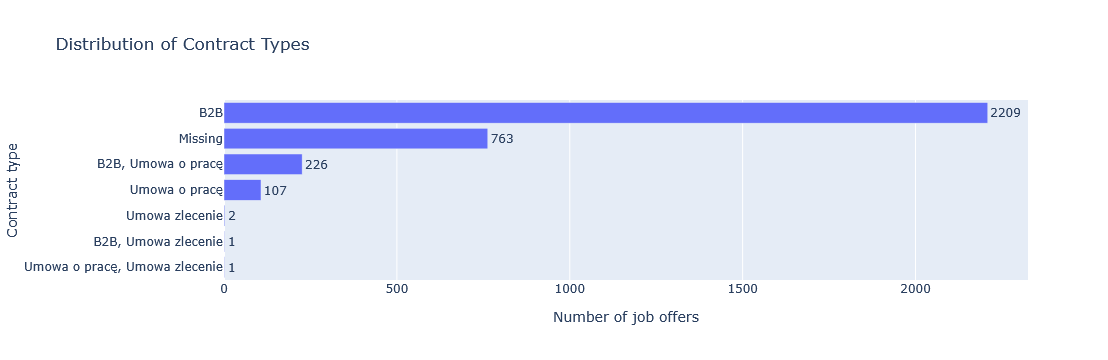

In [44]:
contract_type_plot = (
    contract_type_summary
    .sort_values(
        "job_offers",
        ascending=True
    )
)

fig = px.bar(
    contract_type_plot,
    x="job_offers",
    y="contract_type",
    orientation="h",
    text="job_offers",
    title="Distribution of Contract Types",
    labels={
        "job_offers": "Number of job offers",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    showlegend=False
)

fig.show()

### Key observation

B2B is the dominant contract type in the dataset, while traditional employment contracts appear much less frequently.

A substantial share of offers does not provide contract information, so missing values should be considered when interpreting the distribution.

In [46]:
abc = df.groupby('contract_type')['experience'].count()

In [47]:
abc

contract_type
B2B                              2207
B2B, Umowa o pracę                226
B2B, Umowa zlecenie                 1
Umowa o pracę                     107
Umowa o pracę, Umowa zlecenie       1
Umowa zlecenie                      2
Name: experience, dtype: int64

In [55]:
experience_order = [
    "Junior",
    "Mid",
    "Senior",
    "Expert"
]

contract_experience = (
    pd.crosstab(
        df["experience"],
        df["contract_type"].fillna("Missing"),
        normalize="index"
    )
    * 100
).round(1)

contract_experience = (
    contract_experience
    .reindex(experience_order)
)

contract_experience

contract_type,B2B,"B2B, Umowa o pracę","B2B, Umowa zlecenie",Missing,Umowa o pracę,"Umowa o pracę, Umowa zlecenie",Umowa zlecenie
experience,,,,,,,
Junior,43.6,7.9,0.0,39.3,7.1,0.7,1.4
Mid,67.8,8.6,0.1,19.7,3.8,0.0,0.0
Senior,70.5,5.5,0.0,21.4,2.6,0.0,0.0
Expert,56.1,8.6,0.0,31.7,3.6,0.0,0.0


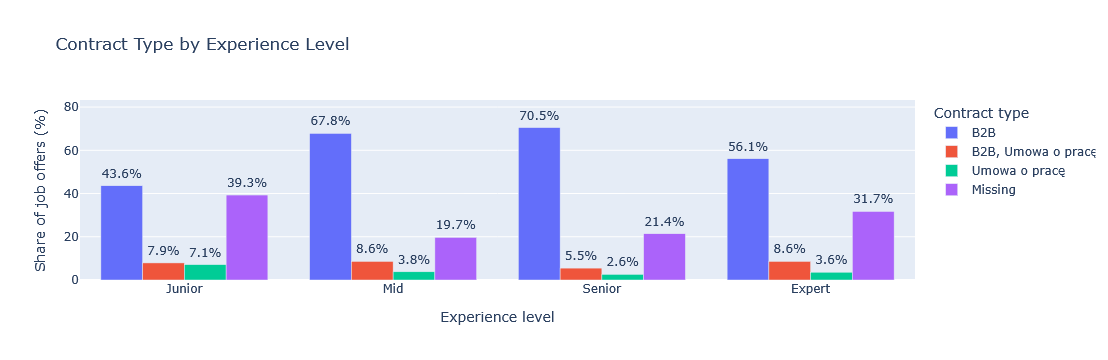

In [56]:
main_contract_types = [
    "B2B",
    "B2B, Umowa o pracę",
    "Umowa o pracę",
    "Missing"
]

contract_experience_plot = (
    contract_experience[
        main_contract_types
    ]
    .reset_index()
    .melt(
        id_vars="experience",
        var_name="contract_type",
        value_name="percentage"
    )
)

fig = px.bar(
    contract_experience_plot,
    x="experience",
    y="percentage",
    color="contract_type",
    barmode="group",
    text="percentage",
    category_orders={
        "experience": [
            "Junior",
            "Mid",
            "Senior",
            "Expert"
        ]
    },
    title="Contract Type by Experience Level",
    labels={
        "experience": "Experience level",
        "percentage": "Share of job offers (%)",
        "contract_type": "Contract type"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.show()